In [6]:
from pathlib import Path



import matplotlib as mpl

import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

import pyabf



from finalwaveform_processor_functions import new_make_waveforms, calculate_midpoints_and_frequencies

from center_vrb import plot_bout_raw_with_vrb_lastcross_and_midpoint_dots

from vrb_plotbouts import between_bout_stats



WORKSPACE_DIR = Path('/Users/Haley/Documents/all_data_analysis_files')

ABF_DIR = Path('/Users/Haley/Desktop/ABF files annotated')

ANNOTATION_FILE = WORKSPACE_DIR / 'all_vrb_annotationsnoNaNs.csv'



ONE_COL = (3.35, 2.4)

TWO_COL = (7.0, 3.0)

TALL_COL = (3.35, 4.8)



def set_pub_style():

    mpl.rcParams.update({

        'figure.dpi': 120,

        'savefig.dpi': 600,

        'savefig.bbox': 'tight',

        'savefig.pad_inches': 0.02,

        'font.family': 'Arial',

        'font.size': 8,

        'axes.titlesize': 8,

        'axes.labelsize': 8,

        'xtick.labelsize': 7,

        'ytick.labelsize': 7,

        'legend.fontsize': 7,

        'axes.linewidth': 0.8,

        'lines.linewidth': 1.2,

        'lines.markersize': 3,

        'pdf.fonttype': 42,

        'ps.fonttype': 42,

        'svg.fonttype': 'none',

    })



def polish_ax(ax, hide_top_right=True):

    if hide_top_right:

        ax.spines['top'].set_visible(False)

        ax.spines['right'].set_visible(False)

    ax.tick_params(direction='out', length=3, width=0.8)

    ax.grid(False)



def finalize_layout(fig=None, suptitle=False, top=0.90):

    fig = fig if fig is not None else plt.gcf()

    if suptitle:

        fig.tight_layout(rect=(0.0, 0.0, 1.0, top))

    else:

        fig.tight_layout()



def save_pub(fig, stem, out_dir='results/figures'):

    out_path = Path(out_dir)

    out_path.mkdir(parents=True, exist_ok=True)

    fig.savefig(out_path / f'{stem}.pdf')

    fig.savefig(out_path / f'{stem}.svg')

    fig.savefig(out_path / f'{stem}.png', dpi=600)



set_pub_style()



c_e_fast = '#0474BA'

c_e_slow = '#00A7E1'

c_i_fast = '#F17720'

c_i_slow = '#FFA630'



palette = [c_e_fast, c_e_slow, c_i_fast, c_i_slow]

labels = ['E-fast', 'E-slow', 'I-fast', 'I-slow']



annotations = pd.read_csv(ANNOTATION_FILE)

trace_name = '2012_08_01_0005'



def abf_file_for_trace(name):

    return ABF_DIR / f'{name}.abf'



def load_trace(name):

    abf = pyabf.ABF(str(abf_file_for_trace(name)))

    ann = annotations[annotations['Trace name'] == name].copy()

    return abf, ann



def concat_channel(abf, channel):

    time_parts = []

    signal_parts = []

    for sweep in range(abf.sweepCount):

        abf.setSweep(sweep, channel=channel)

        time_parts.append(abf.sweepX + sweep * abf.sweepLengthSec)

        signal_parts.append(abf.sweepY.copy())

    return np.concatenate(time_parts), np.concatenate(signal_parts)



print('Setup complete. trace_name =', trace_name)


Setup complete. trace_name = 2012_08_01_0005


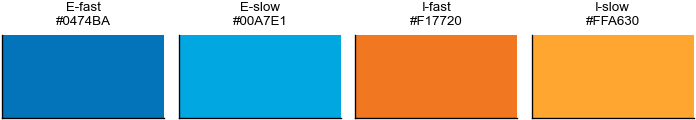

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(6, 1.2))

for ax, color, label in zip(axes, palette, labels):

    ax.add_patch(plt.Rectangle((0, 0), 1, 1, color=color))

    ax.set_xlim(0, 1)

    ax.set_ylim(0, 1)

    ax.set_xticks([])

    ax.set_yticks([])

    ax.set_title(f'{label}\n{color}', fontsize=8)

    polish_ax(ax)

finalize_layout(fig)

plt.show()


## Panel A — Raw Signals

A short raw snippet from the same ABF trace, showing the motoneuron current channel and VRB channel together before any processing.

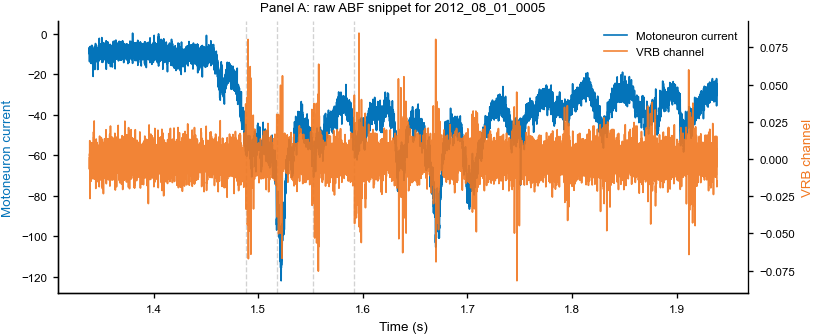

In [8]:
abf_a, ann_a = load_trace(trace_name)

current_channel = int(ann_a['Currents Channel'].iloc[0])

vrb_channel = int(ann_a['VRB Channel'].iloc[0])



time_current, current = concat_channel(abf_a, current_channel)

time_vrb, vrb = concat_channel(abf_a, vrb_channel)



focus_time = float(ann_a['Seconds'].iloc[0])

window_s = 0.60

t0 = max(0.0, focus_time - 0.15)

t1 = t0 + window_s



mask_current = (time_current >= t0) & (time_current <= t1)

mask_vrb = (time_vrb >= t0) & (time_vrb <= t1)



fig, ax1 = plt.subplots(figsize=TWO_COL)

ax2 = ax1.twinx()



ax1.plot(time_current[mask_current], current[mask_current], color=c_e_fast, lw=1.0, label='Motoneuron current')

ax2.plot(time_vrb[mask_vrb], vrb[mask_vrb], color=c_i_fast, lw=1.0, alpha=0.9, label='VRB channel')



for t in ann_a.loc[ann_a['Seconds'].between(t0, t1), 'Seconds'].head(4):

    ax1.axvline(t, color='0.5', ls='--', lw=0.8, alpha=0.35)



ax1.set_title(f'Panel A: raw ABF snippet for {trace_name}')

ax1.set_xlabel('Time (s)')

ax1.set_ylabel('Motoneuron current', color=c_e_fast)

ax2.set_ylabel('VRB channel', color=c_i_fast)



polish_ax(ax1)

ax2.spines['top'].set_visible(False)

ax2.tick_params(direction='out', length=3, width=0.8)



handles1, labels1 = ax1.get_legend_handles_labels()

handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right', frameon=False)

finalize_layout(fig)

plt.show()


## Panel B — Burst Detection on VRB

The VRB channel is plotted with variance bins shaded and BlackDotTime markers returned by the detection step.

Between-bout mean: -0.000047
Between-bout std:  0.007935


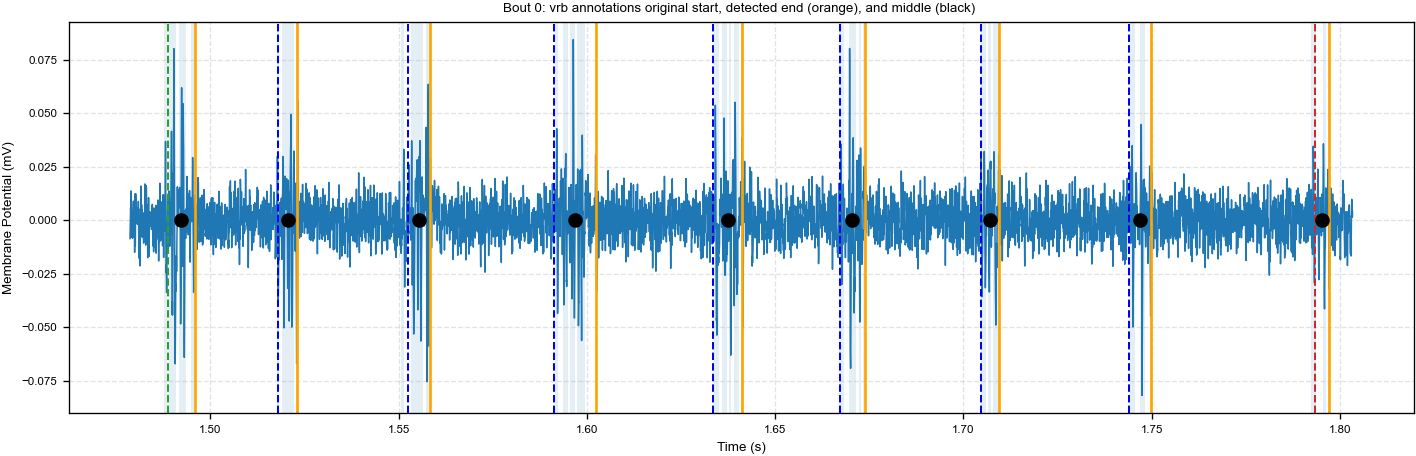

<Figure size 840x360 with 0 Axes>

,BoutIndex,BoutStart,BoutEnd,AnnotationType,AnnotationTime,LastCrossTime,BlackDotTime,SigmaUsed,VarThresholdUsed
0,0,1.47865,1.80331,start,1.48865,1.495856,1.492253,1.0,0.000063
1,0,1.47865,1.80331,vrb,1.51800,1.523127,1.520564,1.0,0.000063
2,0,1.47865,1.80331,vrb,1.55250,1.558189,1.555345,1.0,0.000063
3,0,1.47865,1.80331,vrb,1.59126,1.602342,1.596801,1.0,0.000063
4,0,1.47865,1.80331,vrb,1.63337,1.641300,1.637335,1.0,0.000063


In [12]:
abf_b, ann_b = load_trace(trace_name)

vrb_channel = int(ann_b['VRB Channel'].iloc[0])



between_mean, between_std = between_bout_stats(

    abf_b,

    ann_b,

    channel=vrb_channel,

    seconds_col='Seconds',

    tags_col='Tags',

    start_kw='bout start',

    end_kw='bout end',

)



print(f'Between-bout mean: {between_mean:.6f}')

print(f'Between-bout std:  {between_std:.6f}')



panel_b = plot_bout_raw_with_vrb_lastcross_and_midpoint_dots(

    abf_b,

    ann_b,

    bout_index=0,

    channel=vrb_channel,

    between_std=between_std,

    relative_time=False,

    shade_exceeding=True,

    dot_size=60.0,

    verbose=False,

)



fig = plt.gcf()

fig.set_size_inches(TWO_COL)

for ax in fig.axes:

    polish_ax(ax)

finalize_layout(fig)

plt.show()



panel_b.head()


## Panel C — One Extracted Waveform

A single extracted waveform showing the phase axis from $-0.5$ to $0.5$ and the normalized current output of the extraction step.

0.024414999999972764
last midpoint 8.999767499999699
last blackdot 8.975352499999726
prev mid 8.950937499999753
currents channel 0


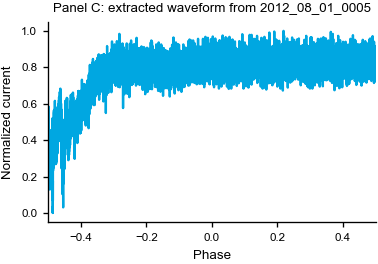

Extracted 20 waveforms. Showing key: (np.float64(0.45019341434563004), 'Excitatory', np.float64(24.52), np.float64(24.97), 'vSMN', np.float64(287.0), 'Low Rin Secondary', '2012_08_01_cell1')


In [10]:
SUMMARY_CSV = Path('/Users/Haley/Desktop/murray-neuroscience-lab/Cleaned, updated files from Spring/summary_spikes2.csv')

cell_meta = pd.read_csv(SUMMARY_CSV)



# Match on date prefix of trace name (e.g. '2012_08_01')

trace_date = '_'.join(trace_name.split('_')[:3])

matches = cell_meta[cell_meta['Cell'].astype(str).str.startswith(trace_date)]

if matches.empty:

    raise ValueError(f'No matching cell found in summary_spikes2.csv for date prefix {trace_date!r}')

cell_row = matches.iloc[0]



abf_c, ann_c_raw = load_trace(trace_name)

ann_c_raw = ann_c_raw.copy().sort_values('BlackDotTime').reset_index(drop=True)

ann_c_raw['Cell Type'] = cell_row.get('Cell Type', 'unknown')

ann_c_raw['Input Resistance'] = cell_row.get('Input Resistance', float('nan'))

ann_c_raw['Group'] = str(cell_row.get('group', '')).strip()

ann_c_raw['Cell'] = str(cell_row['Cell']).strip()

ann_c = calculate_midpoints_and_frequencies(ann_c_raw)



waveforms = new_make_waveforms(abf_c, ann_c)



single_key = sorted(

    waveforms.keys(),

    key=lambda k: (k[0], str(k[1]), str(k[2]), str(k[3]), str(k[4]), str(k[5]), str(k[6]), str(k[7]))

)[0]

single_waveform = waveforms[single_key].copy()



fig, ax = plt.subplots(figsize=ONE_COL)

ax.plot(single_waveform['Phase'], single_waveform['Normalized Current'], color=c_e_slow, lw=1.4)

ax.set_title(f'Panel C: extracted waveform from {trace_name}')

ax.set_xlabel('Phase')

ax.set_ylabel('Normalized current')

ax.set_xlim(-0.5, 0.5)

polish_ax(ax)

finalize_layout(fig)

plt.show()



print(f'Extracted {len(waveforms)} waveforms. Showing key: {single_key}')


## Panel D — Raw Overlaid Waveforms

Several extracted waveforms from the same cell before averaging, showing the trial-to-trial variability that the averaging step collapses.

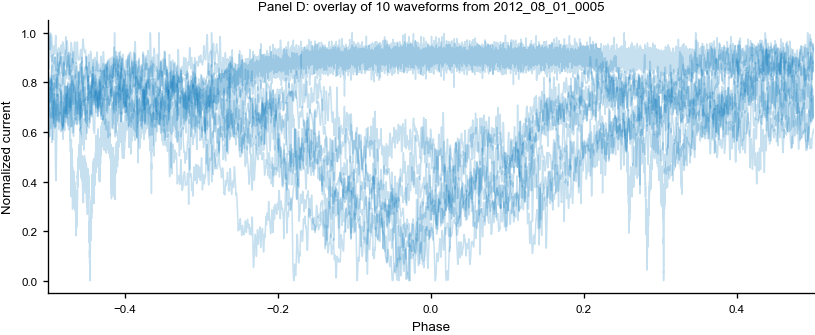

[(np.float64(30.98373353985868),
  'Excitatory',
  np.float64(24.52),
  np.float64(24.97),
  'vSMN',
  np.float64(287.0),
  'Low Rin Secondary',
  '2012_08_01_cell1'),
 (np.float64(26.86186287016107),
  'Excitatory',
  np.float64(24.52),
  np.float64(24.97),
  'vSMN',
  np.float64(287.0),
  'Low Rin Secondary',
  '2012_08_01_cell1'),
 (np.float64(24.394706348696303),
  'Excitatory',
  np.float64(24.52),
  np.float64(24.97),
  'vSMN',
  np.float64(287.0),
  'Low Rin Secondary',
  '2012_08_01_cell1'),
 (np.float64(27.170221437276865),
  'Excitatory',
  np.float64(24.52),
  np.float64(24.97),
  'vSMN',
  np.float64(287.0),
  'Low Rin Secondary',
  '2012_08_01_cell1'),
 (np.float64(27.290714334418002),
  'Excitatory',
  np.float64(24.52),
  np.float64(24.97),
  'vSMN',
  np.float64(287.0),
  'Low Rin Secondary',
  '2012_08_01_cell1'),
 (np.float64(25.926886180942354),
  'Excitatory',
  np.float64(24.52),
  np.float64(24.97),
  'vSMN',
  np.float64(287.0),
  'Low Rin Secondary',
  '2012_08_

In [13]:
max_waveforms = 10

selected_keys = list(waveforms.keys())[:max_waveforms]



fig, ax = plt.subplots(figsize=TWO_COL)

for key in selected_keys:

    wf = waveforms[key]

    ax.plot(wf['Phase'], wf['Normalized Current'], color=c_e_fast, alpha=0.22, lw=0.9)



ax.set_title(f'Panel D: overlay of {len(selected_keys)} waveforms from {trace_name}')

ax.set_xlabel('Phase')

ax.set_ylabel('Normalized current')

ax.set_xlim(-0.5, 0.5)

polish_ax(ax)

finalize_layout(fig)

plt.show()



selected_keys


### Optional next step

If you want, this notebook can also be extended with one final cell that saves each panel to PNG files for direct use in a figure layout.